<a href="https://colab.research.google.com/github/samsyed004/CV-lab/blob/main/lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 03 — Edge Detection Techniques and Their Impact on Classification Performance

Dataset:(HAM10000).



## 0. Setup

In [2]:
!pip install -q opencv-python-headless scikit-learn scikit-image --upgrade
import cv2, sklearn, skimage; print("all imports OK")

all imports OK


In [3]:
import os, glob, time, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 1. Load the dataset


In [4]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

os.makedirs("/content/ham10000", exist_ok=True)
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000 --unzip

meta = pd.read_csv("/content/ham10000/HAM10000_metadata.csv")
img_lookup = {os.path.splitext(os.path.basename(p))[0]: p
              for p in glob.glob("/content/ham10000/**/*.jpg", recursive=True)}
meta["path"] = meta["image_id"].map(img_lookup)
meta = meta.dropna(subset=["path"]).reset_index(drop=True)

# Same three (or more) classes used in Lab 01/02 - edit this list to match exactly.
SELECTED_CLASSES = ["nv", "mel", "bkl"]
meta = meta[meta["dx"].isin(SELECTED_CLASSES)].reset_index(drop=True)
class_names = sorted(meta["dx"].unique())
print("Classes used:", class_names)
print(meta["dx"].value_counts())

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:22<00:00, 246MB/s]

Classes used: ['bkl', 'mel', 'nv']
dx
nv     6705
mel    1113
bkl    1099
Name: count, dtype: int64


## 2. Task 1 — Comparative Edge Detection

Implements all seven detectors: Sobel Gx, Sobel Gy, Sobel gradient magnitude, Prewitt, Laplacian, Laplacian of Gaussian (LoG), and Canny.

In [5]:
IMG_SIZE = 256

def load_gray(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.resize(img, (size, size))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray

def sobel_gx(gray):
    return cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

def sobel_gy(gray):
    return cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

def sobel_magnitude(gray):
    gx, gy = sobel_gx(gray), sobel_gy(gray)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    return np.clip(mag / (mag.max() + 1e-8) * 255, 0, 255).astype(np.uint8)

def prewitt(gray):
    kx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
    ky = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
    gx = cv2.filter2D(gray.astype(np.float32), -1, kx)
    gy = cv2.filter2D(gray.astype(np.float32), -1, ky)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    return np.clip(mag / (mag.max() + 1e-8) * 255, 0, 255).astype(np.uint8)

def laplacian(gray):
    lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
    return np.clip(np.abs(lap) / (np.abs(lap).max() + 1e-8) * 255, 0, 255).astype(np.uint8)

def log_edge(gray, ksize=9, sigma=1.4):
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), sigma)
    lap = cv2.Laplacian(blurred, cv2.CV_64F, ksize=3)
    return np.clip(np.abs(lap) / (np.abs(lap).max() + 1e-8) * 255, 0, 255).astype(np.uint8)

def canny_edge(gray, low=50, high=150):
    return cv2.Canny(gray, low, high)

def sobel_gx_display(gray):
    gx = sobel_gx(gray)
    return np.clip(np.abs(gx) / (np.abs(gx).max() + 1e-8) * 255, 0, 255).astype(np.uint8)

def sobel_gy_display(gray):
    gy = sobel_gy(gray)
    return np.clip(np.abs(gy) / (np.abs(gy).max() + 1e-8) * 255, 0, 255).astype(np.uint8)

### Required figure: Original → Sobel → Prewitt → Laplacian → LoG → Canny, across 3+ classes

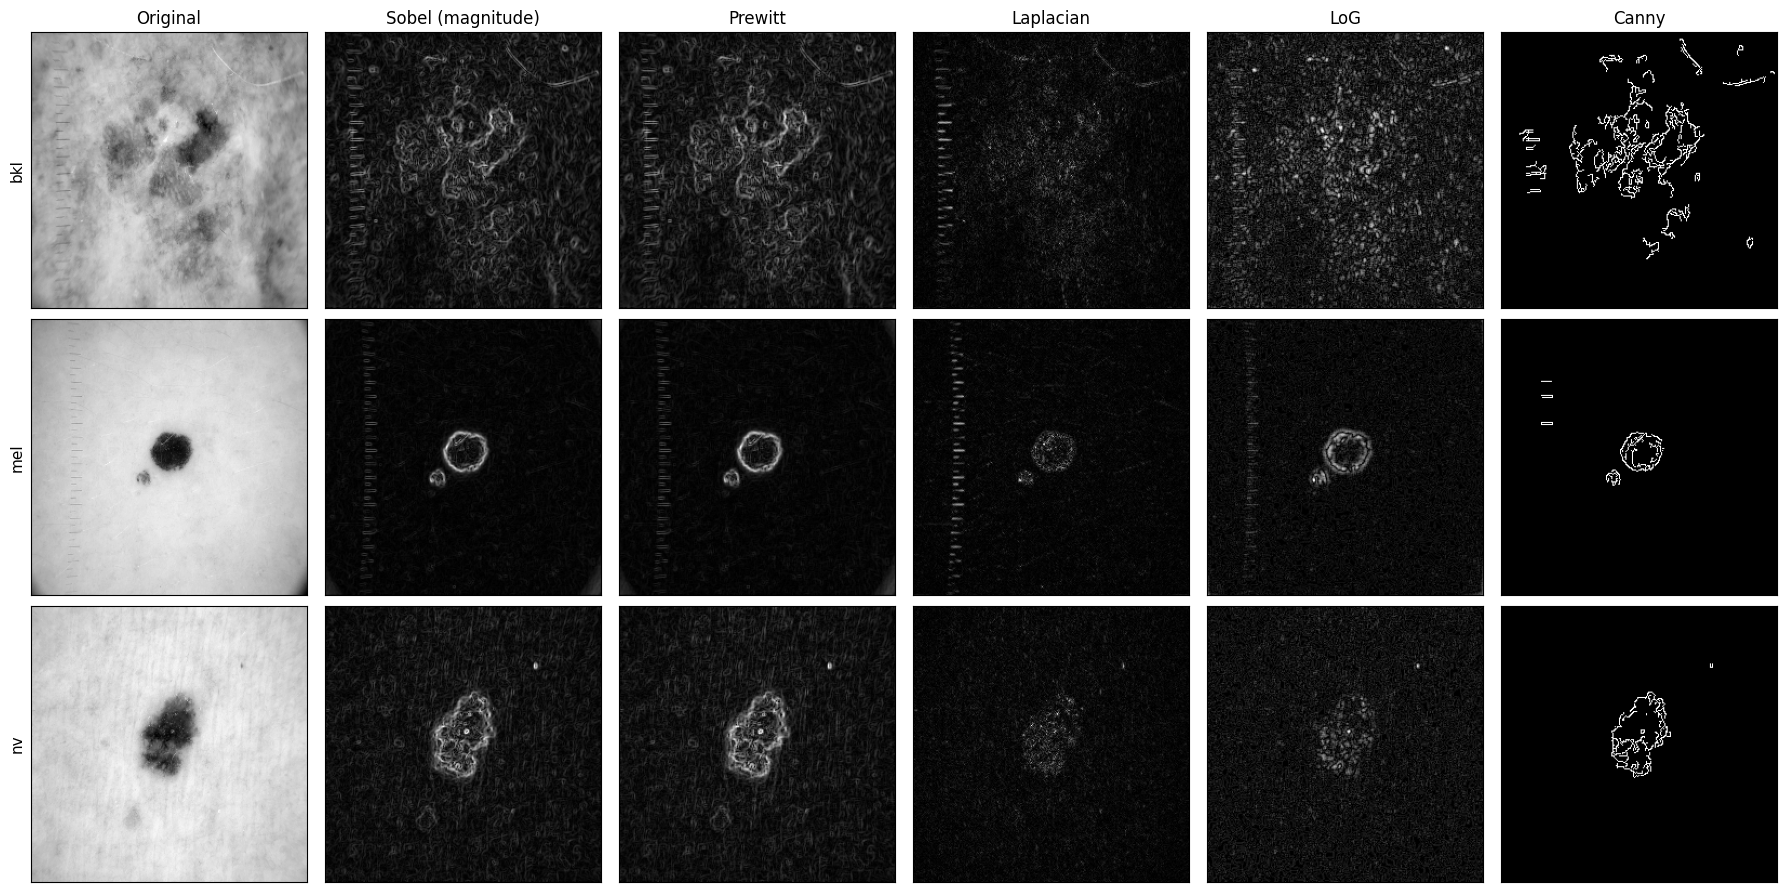

In [6]:
methods = [
    ("Original", lambda g: g),
    ("Sobel (magnitude)", sobel_magnitude),
    ("Prewitt", prewitt),
    ("Laplacian", laplacian),
    ("LoG", log_edge),
    ("Canny", canny_edge),
]

sample_paths = {c: meta[meta["dx"] == c].iloc[0]["path"] for c in class_names[:3]}

fig, axes = plt.subplots(len(sample_paths), len(methods), figsize=(3 * len(methods), 3 * len(sample_paths)))
for i, (cls, path) in enumerate(sample_paths.items()):
    _, gray = load_gray(path)
    for j, (name, fn) in enumerate(methods):
        ax = axes[i][j]
        ax.imshow(fn(gray), cmap="gray")
        if i == 0:
            ax.set_title(name)
        if j == 0:
            ax.set_ylabel(cls, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("/content/task1_edge_comparison.png", dpi=150)
plt.show()

### Sobel Gx vs. Gy individually (for completeness / discussion question 3)

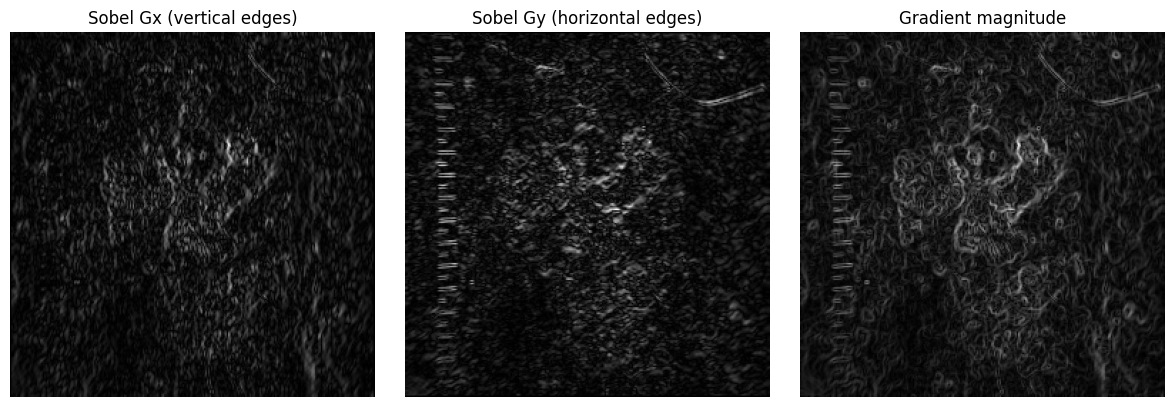

In [7]:
_, gray0 = load_gray(list(sample_paths.values())[0])
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sobel_gx_display(gray0), cmap="gray"); axes[0].set_title("Sobel Gx (vertical edges)")
axes[1].imshow(sobel_gy_display(gray0), cmap="gray"); axes[1].set_title("Sobel Gy (horizontal edges)")
axes[2].imshow(sobel_magnitude(gray0), cmap="gray"); axes[2].set_title("Gradient magnitude")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.savefig("/content/task1_sobel_gx_gy.png", dpi=150)
plt.show()

## 3. Task 2 — Effect of Noise on Edge Detection

In [8]:
def add_gaussian_noise(gray, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, gray.shape)
    noisy = gray.astype(np.float64) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(gray, amount=0.03):
    noisy = gray.copy()
    n_salt = int(amount * gray.size * 0.5)
    n_pepper = int(amount * gray.size * 0.5)
    ys = np.random.randint(0, gray.shape[0], n_salt)
    xs = np.random.randint(0, gray.shape[1], n_salt)
    noisy[ys, xs] = 255
    ys = np.random.randint(0, gray.shape[0], n_pepper)
    xs = np.random.randint(0, gray.shape[1], n_pepper)
    noisy[ys, xs] = 0
    return noisy

def gaussian_filter(gray, ksize=5):
    return cv2.GaussianBlur(gray, (ksize, ksize), 1.0)

def median_filter(gray, ksize=5):
    return cv2.medianBlur(gray, ksize)

def edge_density(edge_img, thresh=30):
    return float((edge_img > thresh).sum()) / edge_img.size

### Visual comparison: original vs. noisy vs. noisy+filtered, for each edge detector

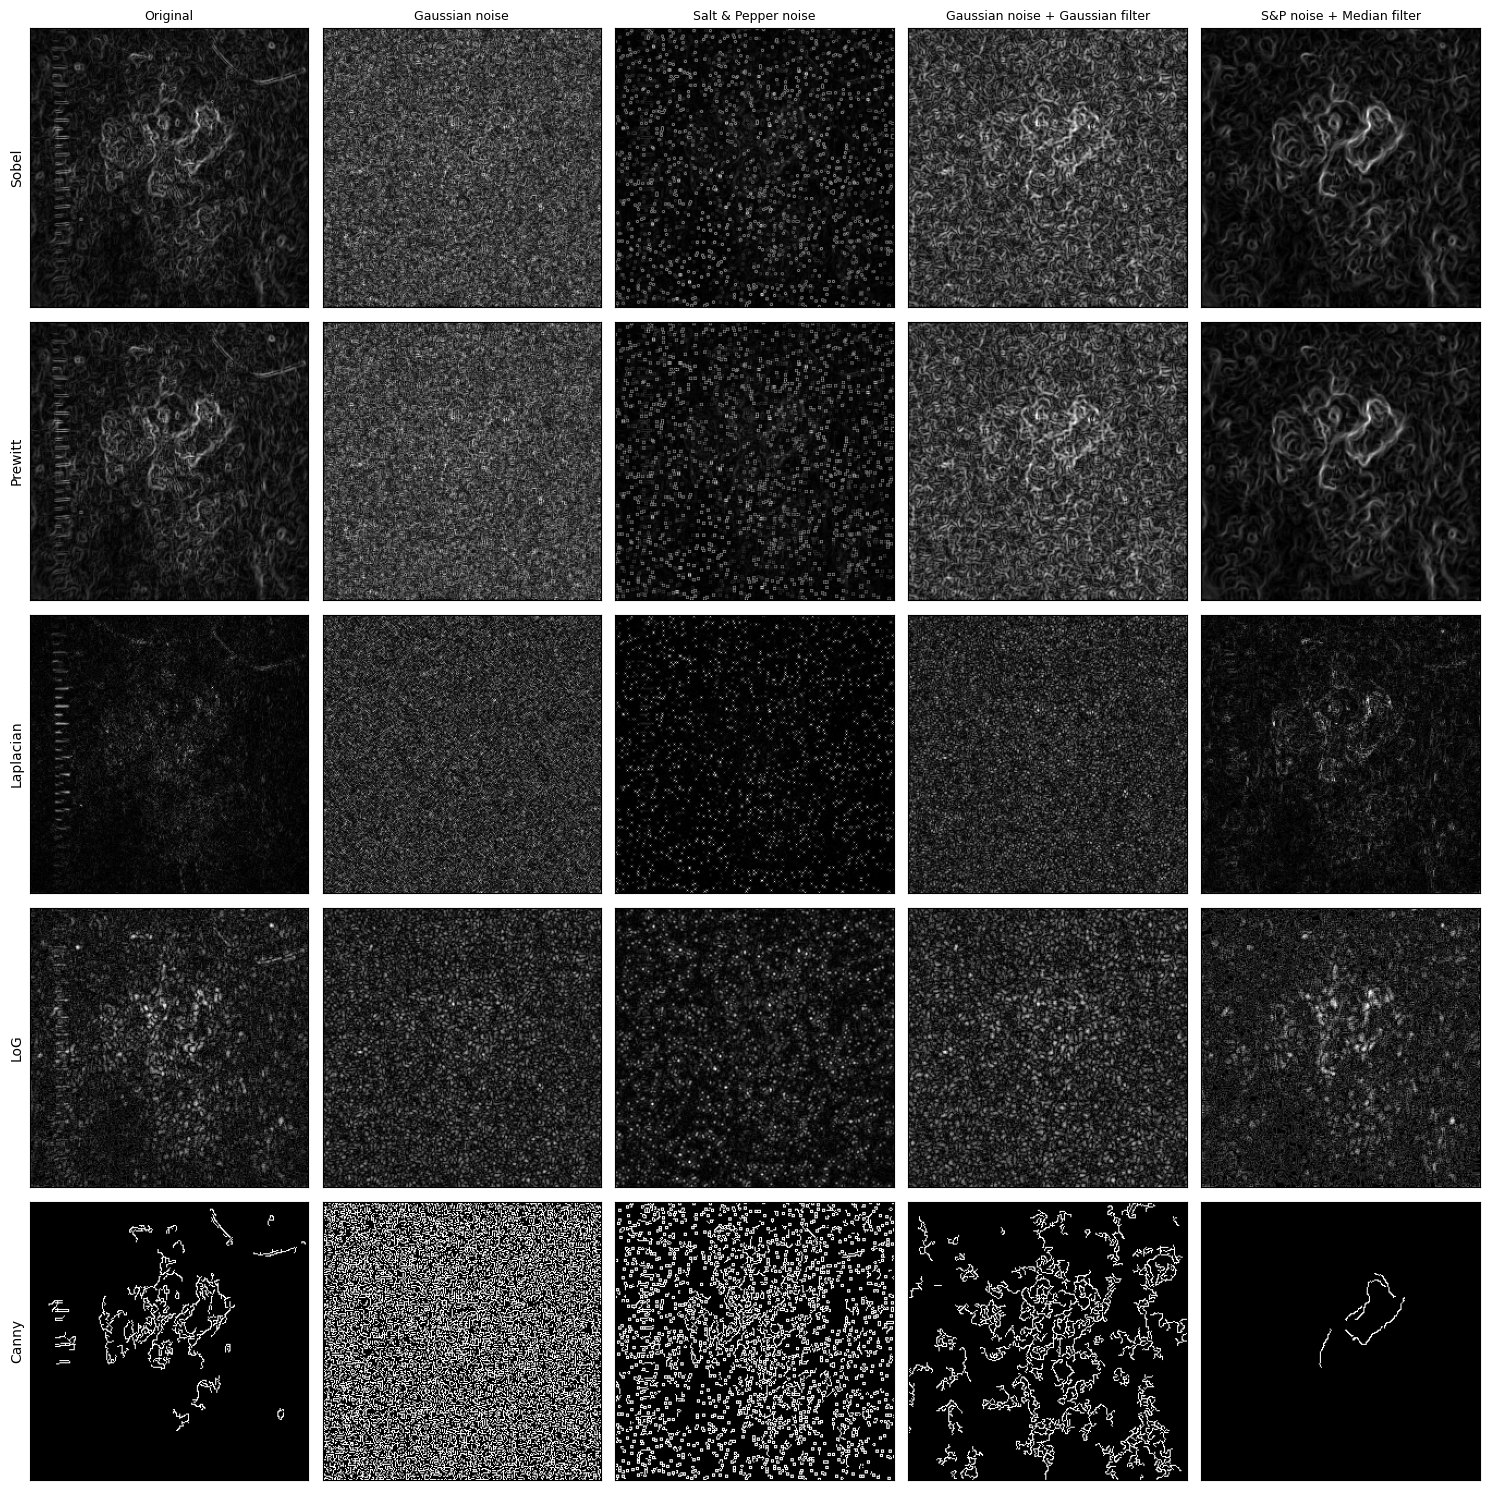

,Edge Detector,Variant,Edge Density (proxy)
0,Sobel,Original,0.3280
1,Sobel,Gaussian noise,0.8333
2,Sobel,Salt & Pepper noise,0.1999
3,Sobel,Gaussian noise + Gaussian filter,0.8170
4,Sobel,S&P noise + Median filter,0.2593
5,Prewitt,Original,0.3509
6,Prewitt,Gaussian noise,0.8369
7,Prewitt,Salt & Pepper noise,0.2007
8,Prewitt,Gaussian noise + Gaussian filter,0.8163
9,Prewitt,S&P noise + Median filter,0.2643


In [9]:
_, base_gray = load_gray(list(sample_paths.values())[0])
gaussian_noisy = add_gaussian_noise(base_gray)
sp_noisy = add_salt_pepper_noise(base_gray)
gaussian_denoised = gaussian_filter(gaussian_noisy)
median_denoised = median_filter(sp_noisy)

variants = [
    ("Original", base_gray),
    ("Gaussian noise", gaussian_noisy),
    ("Salt & Pepper noise", sp_noisy),
    ("Gaussian noise + Gaussian filter", gaussian_denoised),
    ("S&P noise + Median filter", median_denoised),
]
detectors = [("Sobel", sobel_magnitude), ("Prewitt", prewitt), ("Laplacian", laplacian),
             ("LoG", log_edge), ("Canny", canny_edge)]

fig, axes = plt.subplots(len(detectors), len(variants), figsize=(3 * len(variants), 3 * len(detectors)))
edge_density_table = []
for i, (dname, dfn) in enumerate(detectors):
    for j, (vname, vimg) in enumerate(variants):
        edge_img = dfn(vimg)
        ax = axes[i][j]
        ax.imshow(edge_img, cmap="gray")
        if i == 0:
            ax.set_title(vname, fontsize=9)
        if j == 0:
            ax.set_ylabel(dname, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        edge_density_table.append({"Edge Detector": dname, "Variant": vname,
                                    "Edge Density (proxy)": round(edge_density(edge_img), 4)})
plt.tight_layout()
plt.savefig("/content/task2_noise_effect.png", dpi=150)
plt.show()

edge_density_df = pd.DataFrame(edge_density_table)
edge_density_df.to_csv("/content/task2_edge_density_proxy.csv", index=False)
edge_density_df

### Fill in Table 1 using the figure above and `edge_density_df`

`edge_density_df` gives a *quantitative proxy* (fraction of pixels classified as edges) for each detector/variant combination — a big jump in edge density after adding noise indicates false edges; a big drop after filtering (that still preserves the true boundary) indicates good denoising. Use this alongside the visual figure to fill in **Edge Quality**, **Noise Sensitivity**, and **Observations** for the rows required in the report's Table 1 (edge continuity, sharpness, false/broken edges).

In [10]:
table1_template = pd.DataFrame([
    {"Edge Detector": "Sobel",     "Input Image": "Original", "Noise Type": "None",           "Preprocessing": "None"},
    {"Edge Detector": "Sobel",     "Input Image": "Noisy",    "Noise Type": "Gaussian",        "Preprocessing": "None"},
    {"Edge Detector": "Sobel",     "Input Image": "Noisy",    "Noise Type": "Salt & Pepper",   "Preprocessing": "None"},
    {"Edge Detector": "Sobel",     "Input Image": "Noisy",    "Noise Type": "Gaussian",        "Preprocessing": "Gaussian Filter"},
    {"Edge Detector": "Sobel",     "Input Image": "Noisy",    "Noise Type": "Salt & Pepper",   "Preprocessing": "Median Filter"},
    {"Edge Detector": "Prewitt",   "Input Image": "Original", "Noise Type": "None",           "Preprocessing": "None"},
    {"Edge Detector": "Laplacian", "Input Image": "Original", "Noise Type": "None",           "Preprocessing": "None"},
    {"Edge Detector": "LoG",       "Input Image": "Noisy",    "Noise Type": "Gaussian",        "Preprocessing": "Gaussian Filter"},
    {"Edge Detector": "Canny",     "Input Image": "Original", "Noise Type": "None",           "Preprocessing": "Built-in smoothing"},
    {"Edge Detector": "Canny",     "Input Image": "Noisy",    "Noise Type": "Gaussian",        "Preprocessing": "Gaussian Filter"},
    {"Edge Detector": "Canny",     "Input Image": "Noisy",    "Noise Type": "Salt & Pepper",   "Preprocessing": "Median Filter"},
])
table1_template["Edge Quality"] = ""
table1_template["Noise Sensitivity"] = ""
table1_template["Observations"] = ""
table1_template.to_csv("/content/table1_template.csv", index=False)
table1_template

,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality,Noise Sensitivity,Observations
0,Sobel,Original,None,None,,,
1,Sobel,Noisy,Gaussian,None,,,
2,Sobel,Noisy,Salt & Pepper,None,,,
3,Sobel,Noisy,Gaussian,Gaussian Filter,,,
4,Sobel,Noisy,Salt & Pepper,Median Filter,,,
5,Prewitt,Original,None,None,,,
6,Laplacian,Original,None,None,,,
7,LoG,Noisy,Gaussian,Gaussian Filter,,,
8,Canny,Original,None,Built-in smoothing,,,
9,Canny,Noisy,Gaussian,Gaussian Filter,,,


## 4. Task 3 — Parameter Analysis of Canny Edge Detection

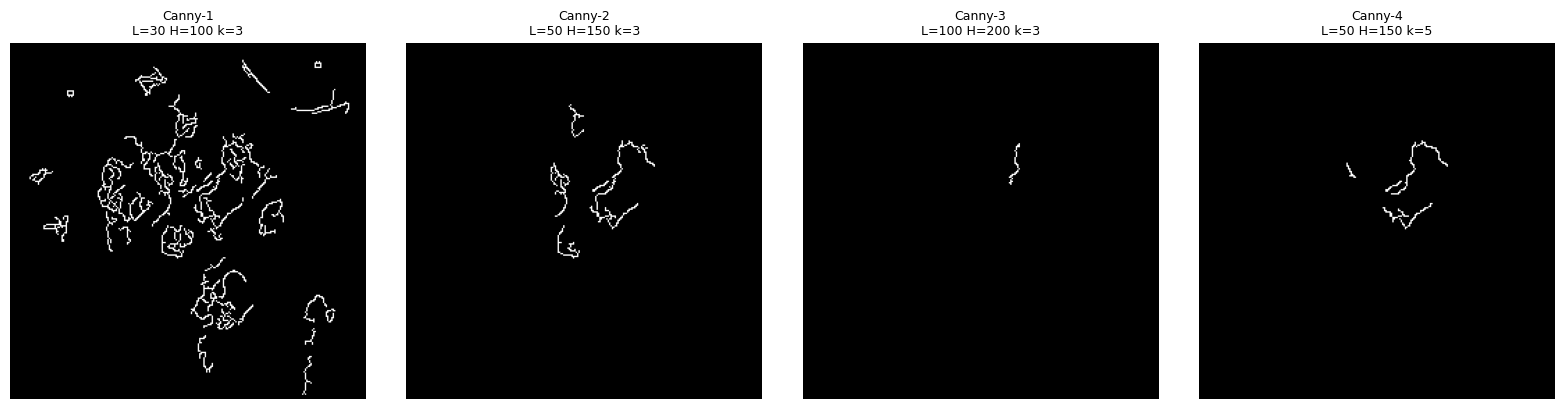

,Configuration,Low Threshold,High Threshold,Kernel Size,Number of Detected Edges (nonzero px),Observation
0,Canny-1,30,100,3x3,2290,
1,Canny-2,50,150,3x3,431,
2,Canny-3,100,200,3x3,43,
3,Canny-4,50,150,5x5,217,


In [11]:
canny_configs = [
    {"name": "Canny-1", "low": 30,  "high": 100, "ksize": 3},
    {"name": "Canny-2", "low": 50,  "high": 150, "ksize": 3},
    {"name": "Canny-3", "low": 100, "high": 200, "ksize": 3},
    {"name": "Canny-4", "low": 50,  "high": 150, "ksize": 5},
]

def canny_with_kernel(gray, low, high, ksize):
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), 1.0)
    return cv2.Canny(blurred, low, high)

fig, axes = plt.subplots(1, len(canny_configs), figsize=(4 * len(canny_configs), 4))
table2_rows = []
for ax, cfg in zip(axes, canny_configs):
    edges = canny_with_kernel(base_gray, cfg["low"], cfg["high"], cfg["ksize"])
    ax.imshow(edges, cmap="gray")
    ax.set_title(f"{cfg['name']}\nL={cfg['low']} H={cfg['high']} k={cfg['ksize']}", fontsize=9)
    ax.axis("off")
    table2_rows.append({
        "Configuration": cfg["name"], "Low Threshold": cfg["low"], "High Threshold": cfg["high"],
        "Kernel Size": f"{cfg['ksize']}x{cfg['ksize']}",
        "Number of Detected Edges (nonzero px)": int((edges > 0).sum()),
        "Observation": "",
    })
plt.tight_layout()
plt.savefig("/content/task3_canny_params.png", dpi=150)
plt.show()

table2_df = pd.DataFrame(table2_rows)
table2_df.to_csv("/content/table2_canny_params.csv", index=False)
table2_df

Lower thresholds generally detect more (and noisier/false) edges; higher thresholds detect fewer but stronger, more continuous edges. Use the printed edge counts and the figure above to fill in **Edge Quality** and **Observation**, and select the configuration you judge best for `BEST_CANNY_CONFIG` below.

In [12]:
BEST_CANNY_CONFIG = {"low": 50, "high": 150, "ksize": 3}   # edit based on Task 3 results above

## 5. Task 4 — Prepare Set A (Raw), Set B (Filtered), Set C (Edge)

`BEST_FILTER` should match whatever your Lab 02 results identified as best (defaults to Gaussian, a common good performer for denoising without excessive detail loss — edit if your Lab 02 results say otherwise).

In [13]:
BEST_FILTER = "Gaussian"   # set to whatever Lab 02 identified as the best filter

def apply_best_filter(img_np):
    if BEST_FILTER == "Average":
        return cv2.blur(img_np, (5, 5))
    if BEST_FILTER == "Gaussian":
        return cv2.GaussianBlur(img_np, (5, 5), 1.0)
    if BEST_FILTER == "Median":
        return cv2.medianBlur(img_np, 5)
    if BEST_FILTER == "Sharpening":
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
        return np.clip(cv2.filter2D(img_np, -1, kernel), 0, 255).astype(np.uint8)
    return img_np

def make_edge_rgb(gray):
    edges = canny_with_kernel(gray, BEST_CANNY_CONFIG["low"], BEST_CANNY_CONFIG["high"], BEST_CANNY_CONFIG["ksize"])
    return np.stack([edges, edges, edges], axis=-1)

SPLIT_SIZE = 300  # images per class kept for this comparison, for a manageable runtime

subset = meta.groupby("dx", group_keys=False).apply(
    lambda g: g.sample(min(len(g), SPLIT_SIZE), random_state=SEED)
).reset_index(drop=True)
class_to_idx = {c: i for i, c in enumerate(class_names)}
subset["label"] = subset["dx"].map(class_to_idx)
NUM_CLASSES = len(class_names)

from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(subset, test_size=0.30, stratify=subset["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

/tmp/ipykernel_648/3416703810.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset = meta.groupby("dx", group_keys=False).apply(


Train: 630 Val: 135 Test: 135


In [14]:
CNN_IMG_SIZE = 128

def load_representation(path, representation):
    img = cv2.imread(path)
    img = cv2.resize(img, (CNN_IMG_SIZE, CNN_IMG_SIZE))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if representation == "raw":
        return img_rgb
    if representation == "filtered":
        return apply_best_filter(img_rgb)
    if representation == "edge":
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        return make_edge_rgb(gray)
    raise ValueError(representation)

### Visual check: Set A vs. Set B vs. Set C

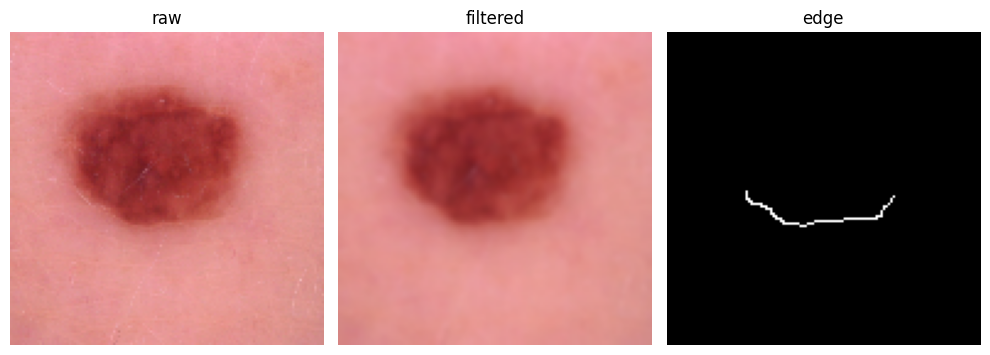

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
p = train_df.iloc[0]["path"]
for ax, rep in zip(axes, ["raw", "filtered", "edge"]):
    ax.imshow(load_representation(p, rep))
    ax.set_title(rep)
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/task4_set_comparison.png", dpi=150)
plt.show()

## 6. Feature extraction for classical classifiers (SVM, Random Forest, KNN)

Classical classifiers need flat feature vectors, not raw images: each image is resized, converted to grayscale, and flattened into a pixel-intensity feature vector for training the classical models.

In [16]:
from sklearn.preprocessing import StandardScaler

FEATURE_SIZE = 32  # small, since classical classifiers work on flattened pixel features

def extract_classical_features(df, representation):
    feats = []
    for p in df["path"]:
        img = load_representation(p, representation)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        small = cv2.resize(gray, (FEATURE_SIZE, FEATURE_SIZE))
        feats.append(small.flatten())
    return np.array(feats, dtype=np.float32)

## 7. CNN datasets/loaders

In [17]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class RepresentationDataset(Dataset):
    def __init__(self, df, representation, augment=False):
        self.df = df.reset_index(drop=True)
        self.representation = representation
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_representation(row["path"], self.representation)
        if self.augment and random.random() < 0.5:
            img = np.fliplr(img).copy()
        t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        t = (t - mean) / std
        return t, row["label"]

def make_cnn_loaders(representation, batch_size=32):
    train_ds = RepresentationDataset(train_df, representation, augment=True)
    val_ds   = RepresentationDataset(val_df,   representation, augment=False)
    test_ds  = RepresentationDataset(test_df,  representation, augment=False)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2),
            DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2),
            DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2))

## 8. CNN Model definitions

**CNN Model 1** — a small custom CNN trained from scratch.
**CNN Model 2** — a pretrained ResNet18 backbone, fine-tuned (frozen features, trained head) for speed.

In [18]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (CNN_IMG_SIZE // 8) ** 2, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def build_cnn_model(name, num_classes):
    if name == "CNN Model 1":
        return SimpleCNN(num_classes)
    if name == "CNN Model 2":
        m = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        for p in m.parameters():
            p.requires_grad = False
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    raise ValueError(name)

## 9. Training / evaluation helpers (shared across all models & representations)

In [19]:
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

CNN_EPOCHS = 5
CNN_LR = 1e-3

def train_cnn(model, train_loader, val_loader, epochs=CNN_EPOCHS, lr=CNN_LR):
    model = model.to(DEVICE)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable, lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    return model

def evaluate_cnn(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            p = model(x).argmax(1).cpu().numpy()
            preds.extend(p)
            labels.extend(y.numpy())
    return np.array(labels), np.array(preds)

def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred) * 100, 2),
        "Precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
        "Recall": round(recall_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
        "F1-Score": round(f1_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
    }

## 10. Run all models × all three representations (Set A / B / C)

In [20]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

REPRESENTATIONS = {"Raw (Lab 1)": "raw", "Filtered (Lab 2)": "filtered", "Edge (Lab 3)": "edge"}
CLASSICAL_MODELS = {
    "SVM": lambda: SVC(kernel="rbf"),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "KNN": lambda: KNeighborsClassifier(n_neighbors=7),
}
CNN_MODEL_NAMES = ["CNN Model 1", "CNN Model 2"]

results = []          # for Table 3
confusion_data = {}   # (model, representation) -> (y_true, y_pred)

# --- classical classifiers ---
for rep_label, rep_key in REPRESENTATIONS.items():
    X_train = extract_classical_features(train_df, rep_key)
    X_test  = extract_classical_features(test_df,  rep_key)
    y_train = train_df["label"].values
    y_test  = test_df["label"].values

    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    for clf_name, clf_fn in CLASSICAL_MODELS.items():
        clf = clf_fn()
        t0 = time.time()
        clf.fit(X_train_s, y_train)
        train_time = time.time() - t0

        t0 = time.time()
        y_pred = clf.predict(X_test_s)
        infer_time_ms = (time.time() - t0) / len(X_test_s) * 1000

        metrics = compute_metrics(y_test, y_pred)
        results.append({"Model": clf_name, "Representation": rep_label, **metrics,
                         "Training Time (s)": round(train_time, 2),
                         "Inference Time (ms)": round(infer_time_ms, 3)})
        confusion_data[(clf_name, rep_label)] = (y_test, y_pred)
        print(f"{clf_name} | {rep_label}: {metrics}")

SVM | Raw (Lab 1): {'Accuracy': 60.74, 'Precision': 61.19, 'Recall': 60.74, 'F1-Score': 60.6}
Random Forest | Raw (Lab 1): {'Accuracy': 60.0, 'Precision': 60.92, 'Recall': 60.0, 'F1-Score': 60.19}
KNN | Raw (Lab 1): {'Accuracy': 45.93, 'Precision': 46.85, 'Recall': 45.93, 'F1-Score': 43.51}
SVM | Filtered (Lab 2): {'Accuracy': 61.48, 'Precision': 61.79, 'Recall': 61.48, 'F1-Score': 61.32}
Random Forest | Filtered (Lab 2): {'Accuracy': 57.78, 'Precision': 58.32, 'Recall': 57.78, 'F1-Score': 57.72}
KNN | Filtered (Lab 2): {'Accuracy': 46.67, 'Precision': 48.27, 'Recall': 46.67, 'F1-Score': 44.12}
SVM | Edge (Lab 3): {'Accuracy': 50.37, 'Precision': 48.79, 'Recall': 50.37, 'F1-Score': 46.57}
Random Forest | Edge (Lab 3): {'Accuracy': 49.63, 'Precision': 49.04, 'Recall': 49.63, 'F1-Score': 48.99}
KNN | Edge (Lab 3): {'Accuracy': 31.85, 'Precision': 28.69, 'Recall': 31.85, 'F1-Score': 21.71}


In [21]:
# --- CNN models ---
for rep_label, rep_key in REPRESENTATIONS.items():
    train_loader, val_loader, test_loader = make_cnn_loaders(rep_key)
    for cnn_name in CNN_MODEL_NAMES:
        print(f"\n=== Training {cnn_name} | {rep_label} ===")
        model = build_cnn_model(cnn_name, NUM_CLASSES)

        t0 = time.time()
        model = train_cnn(model, train_loader, val_loader)
        train_time = time.time() - t0

        t0 = time.time()
        y_true, y_pred = evaluate_cnn(model, test_loader)
        infer_time_ms = (time.time() - t0) / len(y_true) * 1000

        metrics = compute_metrics(y_true, y_pred)
        results.append({"Model": cnn_name, "Representation": rep_label, **metrics,
                         "Training Time (s)": round(train_time, 2),
                         "Inference Time (ms)": round(infer_time_ms, 3)})
        confusion_data[(cnn_name, rep_label)] = (y_true, y_pred)
        print(f"{cnn_name} | {rep_label}: {metrics}")
        model.cpu(); torch.cuda.empty_cache()


=== Training CNN Model 1 | Raw (Lab 1) ===
CNN Model 1 | Raw (Lab 1): {'Accuracy': 68.15, 'Precision': 69.05, 'Recall': 68.15, 'F1-Score': 68.24}

=== Training CNN Model 2 | Raw (Lab 1) ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


CNN Model 2 | Raw (Lab 1): {'Accuracy': 61.48, 'Precision': 62.47, 'Recall': 61.48, 'F1-Score': 61.27}

=== Training CNN Model 1 | Filtered (Lab 2) ===
CNN Model 1 | Filtered (Lab 2): {'Accuracy': 71.11, 'Precision': 73.63, 'Recall': 71.11, 'F1-Score': 71.03}

=== Training CNN Model 2 | Filtered (Lab 2) ===
CNN Model 2 | Filtered (Lab 2): {'Accuracy': 66.67, 'Precision': 66.55, 'Recall': 66.67, 'F1-Score': 66.49}

=== Training CNN Model 1 | Edge (Lab 3) ===
CNN Model 1 | Edge (Lab 3): {'Accuracy': 45.19, 'Precision': 44.29, 'Recall': 45.19, 'F1-Score': 44.59}

=== Training CNN Model 2 | Edge (Lab 3) ===
CNN Model 2 | Edge (Lab 3): {'Accuracy': 56.3, 'Precision': 56.28, 'Recall': 56.3, 'F1-Score': 56.21}


## 11. Table 3 — Cross-Lab Classification Performance Comparison

In [22]:
results_df = pd.DataFrame(results)

# Pivot into the exact Table 3 layout: one row per model, one accuracy column per representation
acc_pivot = results_df.pivot(index="Model", columns="Representation", values="Accuracy")
acc_pivot = acc_pivot[["Raw (Lab 1)", "Filtered (Lab 2)", "Edge (Lab 3)"]]
acc_pivot.columns = ["Accuracy Raw (Lab 1)", "Accuracy Filtered (Lab 2)", "Accuracy Edge (Lab 3)"]

# Precision/Recall/F1/times shown per-representation in the long-format table (more informative);
# the docx Table 3 layout only has one column each, so also produce an "Edge (Lab 3)" summary row set,
# since edge-based classification is the lab's focus.
edge_only = results_df[results_df["Representation"] == "Edge (Lab 3)"].set_index("Model")

table3_df = acc_pivot.join(edge_only[["Precision", "Recall", "F1-Score", "Training Time (s)", "Inference Time (ms)"]])
table3_df = table3_df.reset_index()
print("Table 3 (Precision/Recall/F1/Training/Inference reported for the Edge representation, per the docx template):")
table3_df

results_df.to_csv("/content/table3_full_long_format.csv", index=False)
table3_df.to_csv("/content/table3_docx_format.csv", index=False)
table3_df

Table 3 (Precision/Recall/F1/Training/Inference reported for the Edge representation, per the docx template):


,Model,Accuracy Raw (Lab 1),Accuracy Filtered (Lab 2),Accuracy Edge (Lab 3),Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,CNN Model 1,68.15,71.11,45.19,44.29,45.19,44.59,17.95,5.683
1,CNN Model 2,61.48,66.67,56.30,56.28,56.30,56.21,17.76,5.991
2,KNN,45.93,46.67,31.85,28.69,31.85,21.71,0.00,0.054
3,Random Forest,60.00,57.78,49.63,49.04,49.63,48.99,0.81,0.504
4,SVM,60.74,61.48,50.37,48.79,50.37,46.57,0.21,0.397


## 12. Task 6 — Visual comparison for the best-performing model

Best-performing model overall: CNN Model 1


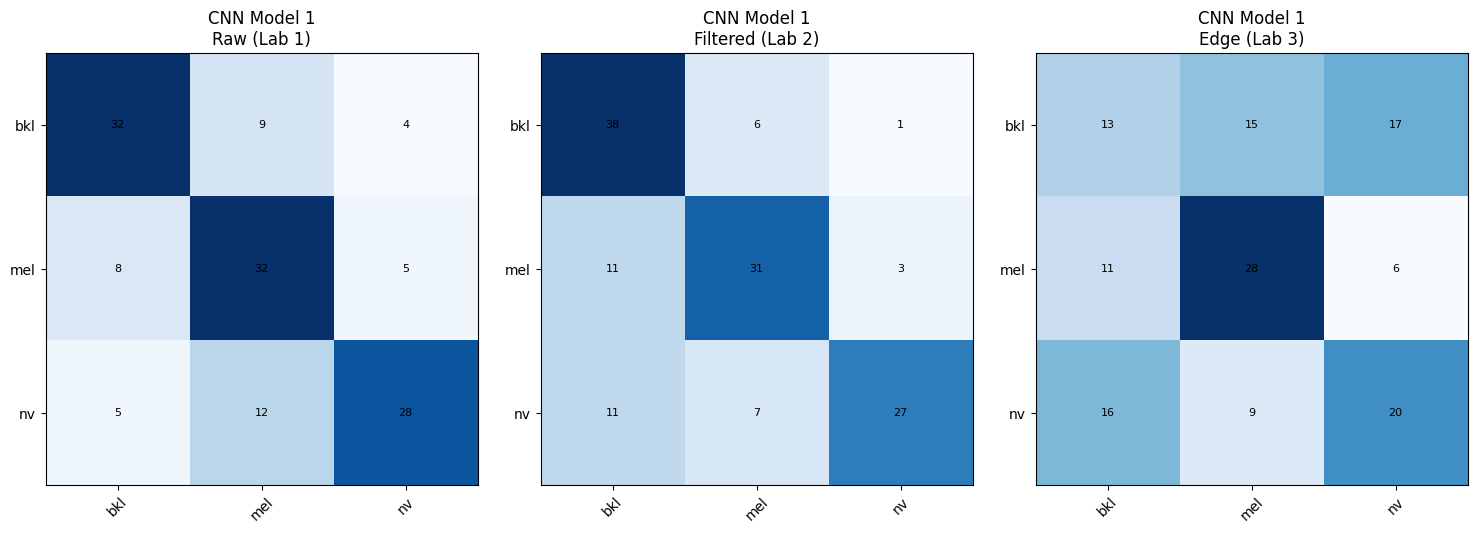

In [23]:
best_model = results_df.loc[results_df["Accuracy"].idxmax(), "Model"]
print("Best-performing model overall:", best_model)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, rep_label in zip(axes, REPRESENTATIONS.keys()):
    y_true, y_pred = confusion_data[(best_model, rep_label)]
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{best_model}\n{rep_label}")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45)
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("/content/task6_confusion_matrices.png", dpi=150)
plt.show()

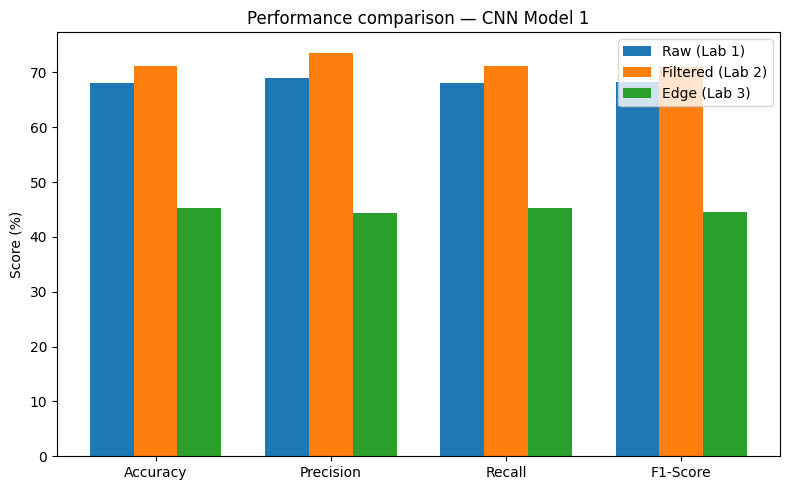

In [24]:
best_rows = results_df[results_df["Model"] == best_model].set_index("Representation")
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics_to_plot))
width = 0.25
for i, rep_label in enumerate(REPRESENTATIONS.keys()):
    vals = [best_rows.loc[rep_label, m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=rep_label)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score (%)")
ax.set_title(f"Performance comparison — {best_model}")
ax.legend()
plt.tight_layout()
plt.savefig("/content/task6_performance_bars.png", dpi=150)
plt.show()

**Discuss (Task 6):** compare the three bars/confusion matrices above — does the Edge (Lab 3) representation improve or reduce classification performance relative to Raw and Filtered? Use the actual numbers in `best_rows` as evidence.

## 13. Export everything

In [25]:
with pd.ExcelWriter("/content/lab03_results.xlsx") as writer:
    table1_template.to_excel(writer, sheet_name="Table1_Noise_Template", index=False)
    edge_density_df.to_excel(writer, sheet_name="Table1_Edge_Density_Proxy", index=False)
    table2_df.to_excel(writer, sheet_name="Table2_Canny_Params", index=False)
    table3_df.to_excel(writer, sheet_name="Table3_CrossLab", index=False)
    results_df.to_excel(writer, sheet_name="Table3_Full_LongFormat", index=False)

from google.colab import files as colab_files
colab_files.download("/content/lab03_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. Discussion Questions

1. **Most noise-sensitive detector?** → Compare `edge_density_df` rows for each detector between 'Original' and the noisy variants; the detector with the largest jump (most false edges) or largest drop (edges destroyed by noise) is most sensitive. Laplacian/LoG (second-order, high-frequency sensitive) are typically the most affected.
2. **Effect of Gaussian/Median filtering?** → Compare the noisy vs. noisy+filtered columns in the Task 2 figure and `edge_density_df`; filtering should reduce false edges from noise but can also blur true fine boundaries.
3. **Effect of Canny thresholds?** → `table2_df`'s 'Number of Detected Edges' column, from Task 3; lower thresholds → more (and noisier) edges, higher thresholds → fewer, stronger, more continuous edges.
4. **Edge maps vs. raw for classification?** → `table3_df` / `results_df`, comparing Accuracy/F1 across 'Raw (Lab 1)' vs. 'Edge (Lab 3)' for each model.
5. **Information lost in edge maps?** → texture, color, and intensity/shading information are discarded — relevant since these often carry diagnostic signal in dermatoscopic images (e.g. pigmentation patterns).
6. **Classical vs. CNN-learned edge features?** → CNNs learn task-optimized, multi-scale edge/texture filters jointly with the classification objective, rather than a single fixed, hand-tuned edge operator.
7. **Best representation overall?** → `results_df` sorted by Accuracy/F1 across all three representations and all five models — cite the specific best-performing (model, representation) pair as evidence.